# Calculate all subjects' dissim ~ genmag, spread

20251203 ~ 20260102

To create the library, implement and test the function here.

Calculate genmag and spread then store in work/data/processed as hdf style.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from qstr_dataset import paths

print("Project root:", paths.PROJECT_ROOT)


from qstr_diversity import core, viz

Project root: /home/jovyan/work


In [2]:
d_path = paths.source("Amy_pilot", "raw", "Amy_dissimilarity.csv")
unique_words = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "brown", "grey", "black", "happiness", "joy", "confidence", "calm", "boredom", "confusion", "anxiety", "fear", "sadness", "defeated", "anger", "envy", "disgust"]
n_sub = 120
raw = pd.read_csv(d_path, header=None)
raw.drop(columns=0, inplace=True)
raw

,1,2,3,4,5,6,7,8,9,10,...,244,245,246,247,248,249,250,251,252,253
0,brown,orange,red,black,green,red,envy,fear,pink,blue,...,blue,blue,fear,purple,disgust,calm,orange,green,brown,anxiety
1,anger,anxiety,yellow,blue,calm,pink,joy,anger,green,anger,...,envy,anxiety,happiness,confidence,defeated,happiness,pink,disgust,joy,boredom
2,6,2,2,1,0,0,7,0,2,6,...,1,2,7,2,5,2,3,0,4,5
3,6,6,3,6,6,6,7,6,3,7,...,6,7,7,6,1,6,4,6,6,1
4,7,7,0,2,3,3,7,5,3,7,...,6,6,7,6,1,1,3,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,6,6,0,0,5,0,2,0,1,5,...,5,5,2,5,3,1,3,6,7,2
118,7,7,6,5,4,2,7,2,5,7,...,3,6,7,3,2,0,2,1,7,7
119,7,7,4,3,3,2,7,3,5,7,...,5,7,7,2,6,0,1,7,7,4
120,7,7,1,2,3,0,6,2,3,5,...,4,6,6,5,3,3,4,2,6,3


In [3]:
# define t

t1 = np.logspace(-4, -1, 20, endpoint=False)   # 10^-4 ～ 10^-1
t2 = np.logspace(-1,  2, 500, endpoint=False)  # 10^-1 ～ 10^2
t3 = np.logspace(2,  4, 20, endpoint=False)    # 10^2 ～ 10^4
t4 = np.logspace(4, 8, 20, endpoint=True)

t_all = np.concatenate([t1, t2, t3, t4])

In [4]:
genmag_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_all = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_all = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

In [5]:
h5_path = paths.interim("amy_processeddata_all.h5")

with pd.HDFStore(h5_path, mode="w") as store:

    for sub in range(n_sub):
        print(f'subject: {sub}')
        dissim_mtx = core.create_dissim_amy(raw, sub_no=sub, unique_words=unique_words)
        dist = core.cal_dissim2dist(dissim_mtx)
        store.put(f"/dissim/sub_{sub:03d}", dissim_mtx, format="fixed")

        for i_t, t in enumerate(t_all):
            sim = core.cal_dist2sim(dist, t)
            genmag = core.cal_sim2genmag(sim)
            genmag_all.iloc[sub, i_t] = genmag

            spr = core.cal_dist2spread(dist, t)
            spr_all.iloc[sub, i_t] = spr

            A = sim.to_numpy()
            is_pd = core.check_positivedefinite(A)
            positive_definite_t_all.iloc[sub, i_t] = bool(is_pd)

subject: 0
subject: 1
subject: 2
subject: 3
subject: 4
subject: 5
subject: 6
subject: 7
subject: 8
subject: 9
subject: 10
subject: 11
subject: 12
subject: 13
subject: 14
subject: 15
subject: 16
subject: 17
subject: 18
subject: 19
subject: 20
subject: 21
subject: 22
subject: 23
subject: 24
subject: 25
subject: 26
subject: 27
subject: 28
subject: 29
subject: 30
subject: 31
subject: 32
subject: 33
subject: 34
subject: 35
subject: 36
subject: 37
subject: 38
subject: 39
subject: 40
subject: 41
subject: 42
subject: 43
subject: 44
subject: 45
subject: 46
subject: 47
subject: 48
subject: 49
subject: 50
subject: 51
subject: 52
subject: 53
subject: 54
subject: 55
subject: 56
subject: 57
subject: 58
subject: 59
subject: 60
subject: 61
subject: 62
subject: 63
subject: 64
subject: 65
subject: 66
subject: 67
subject: 68
subject: 69
subject: 70
subject: 71
subject: 72
subject: 73
subject: 74
subject: 75
subject: 76
subject: 77
subject: 78
subject: 79
subject: 80
subject: 81
subject: 82
subject: 83
su

In [6]:
if genmag_all.columns.is_unique is False or spr_all.columns.is_unique is False:
    raise ValueError("Keys of columns are not unique. Recommend checking t setting.")


positive_definite_df = positive_definite_t_all.astype("bool") 
with pd.HDFStore(h5_path, mode="a") as store:
    store.put("/metrics/genmag", genmag_all, format="fixed")
    store.put("/metrics/spread", spr_all, format="fixed")
    store.put("/metrics/positivedefinite", positive_definite_df, format="fixed")

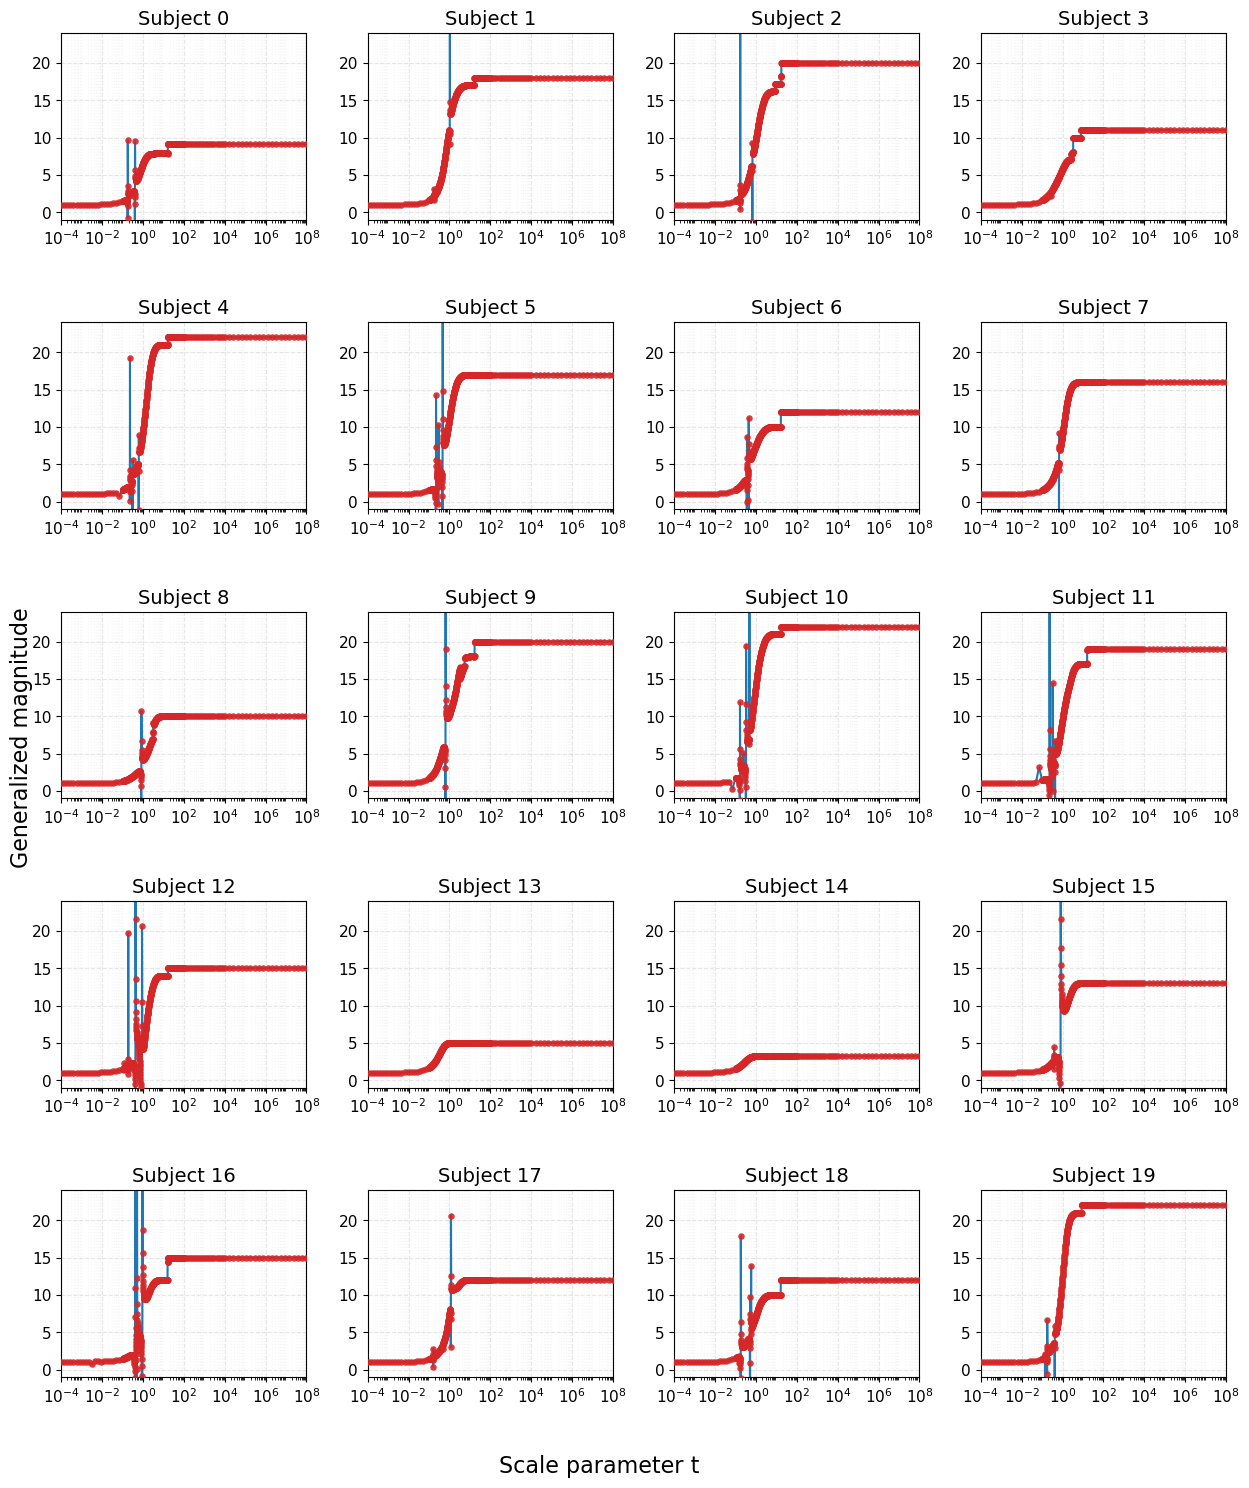

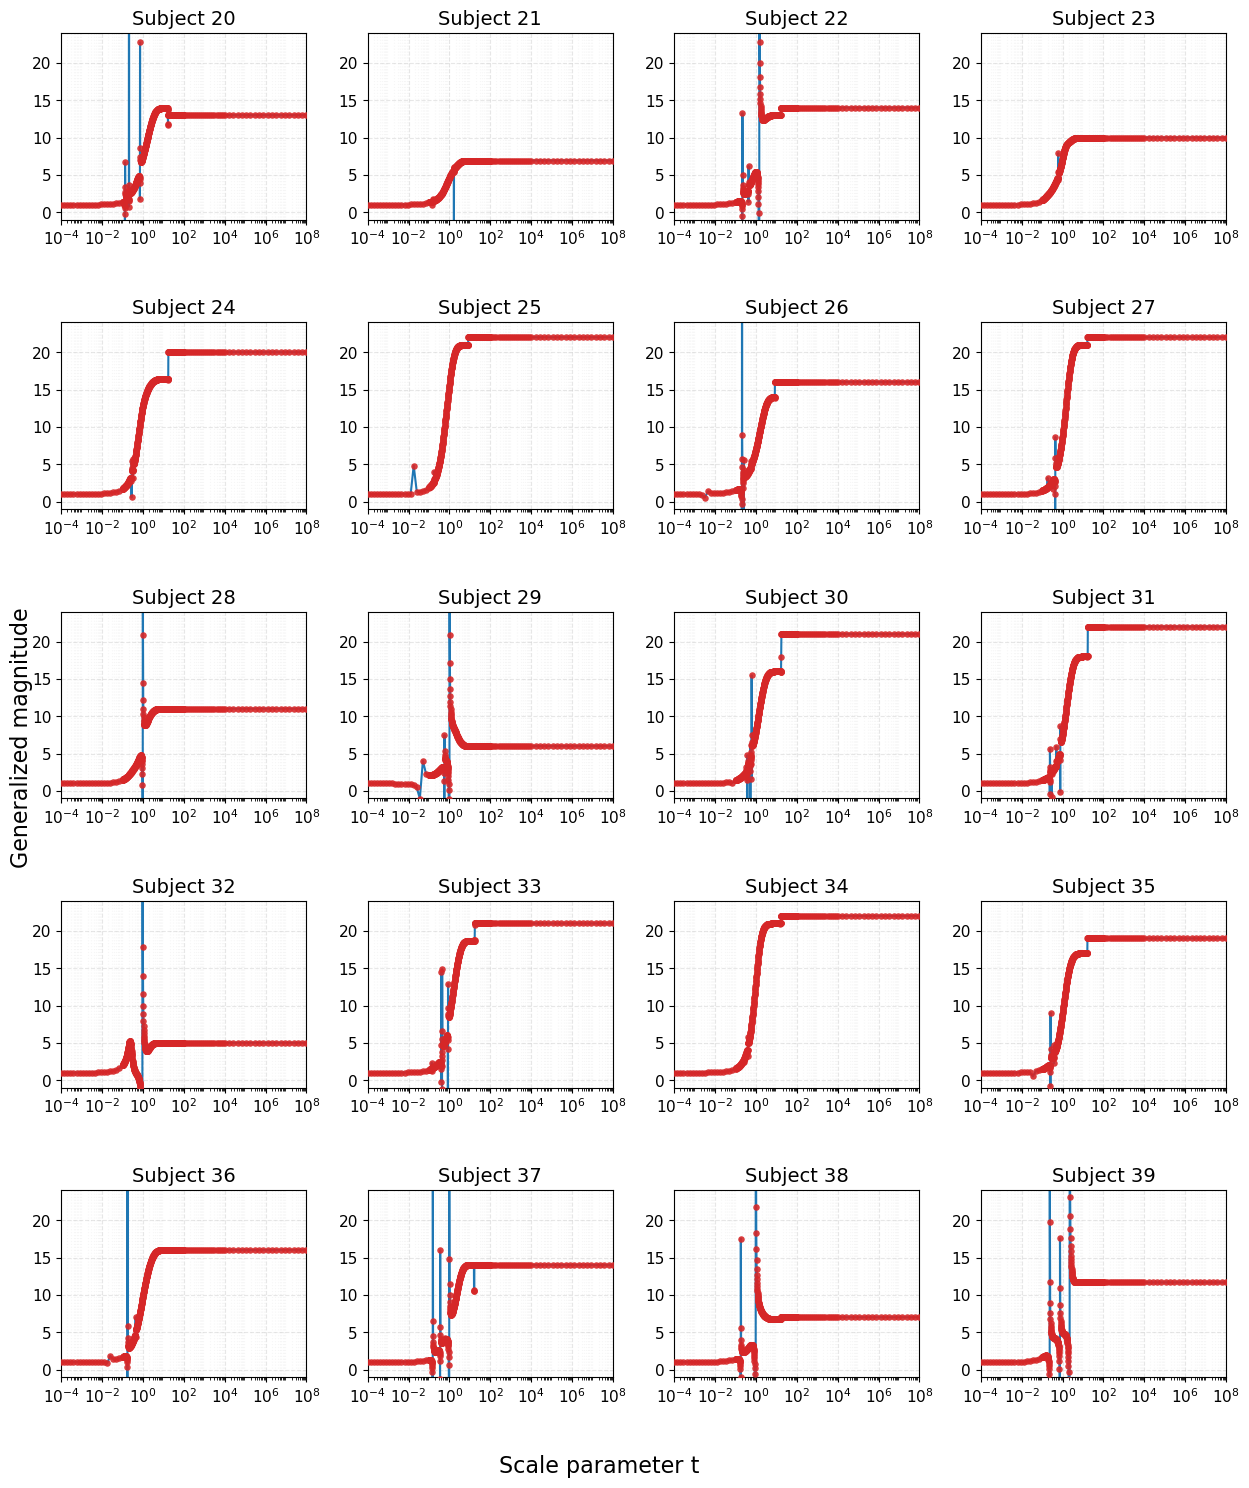

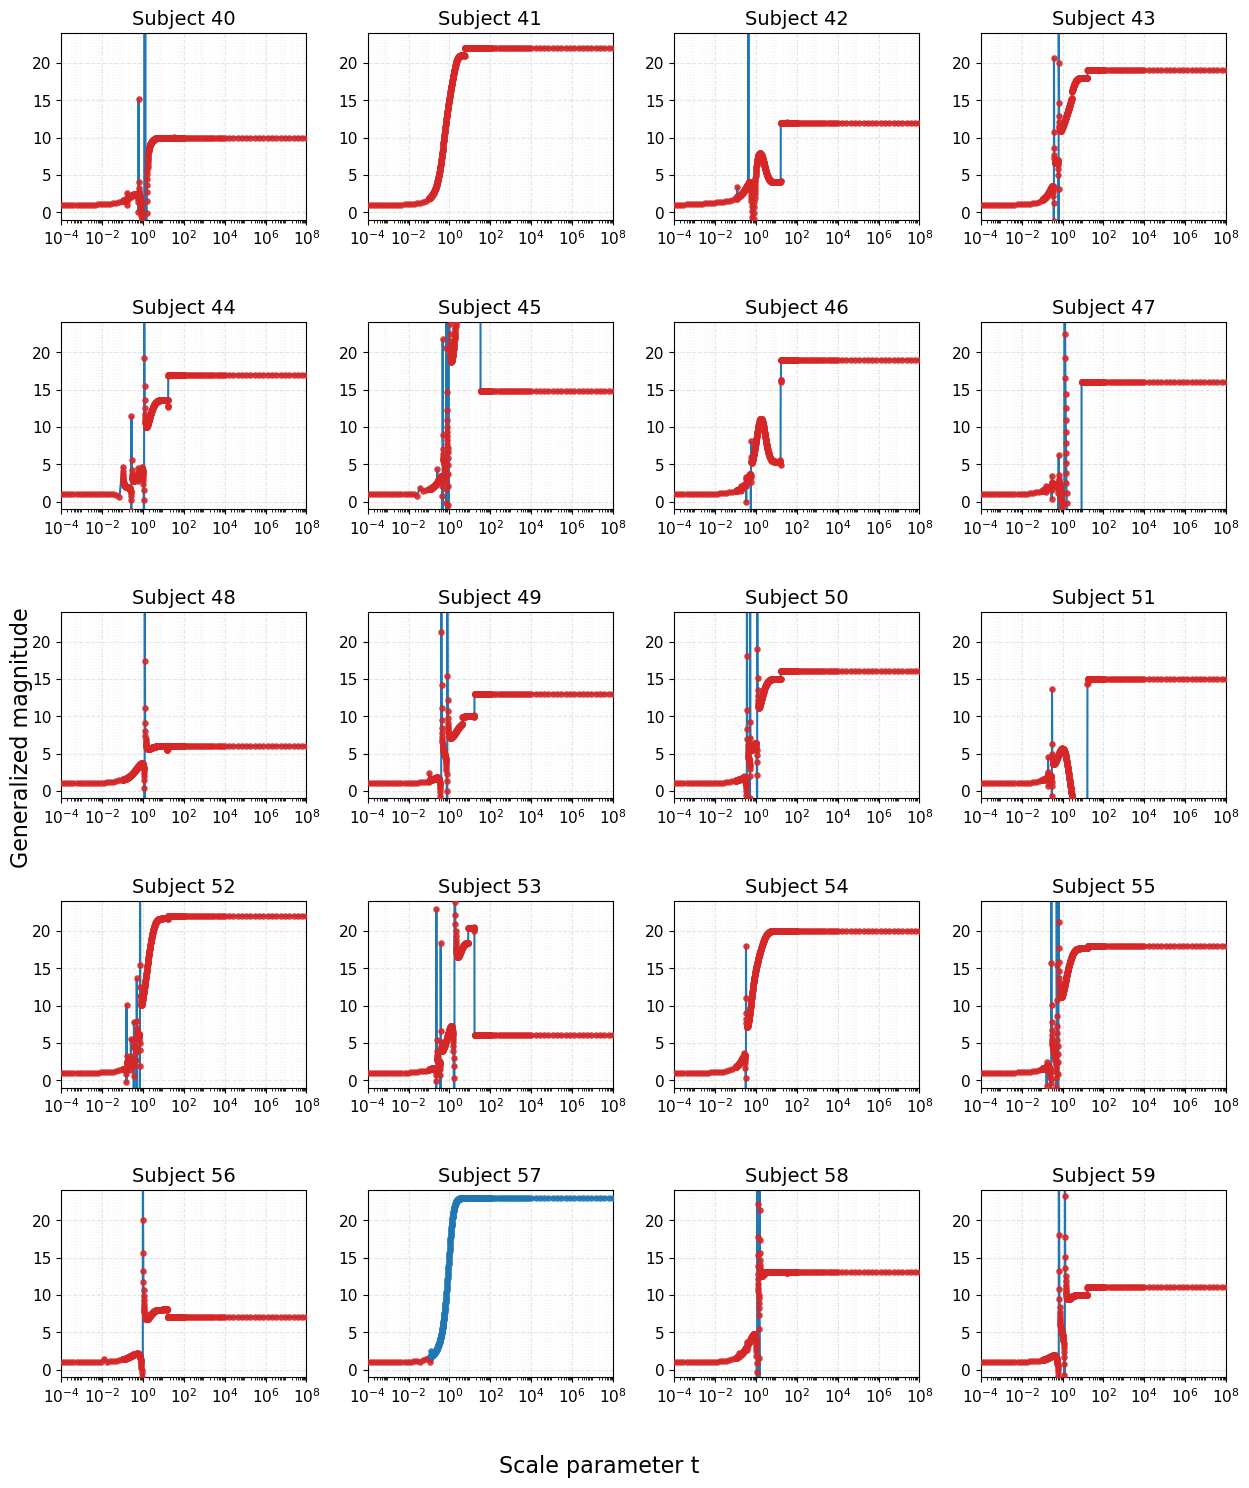

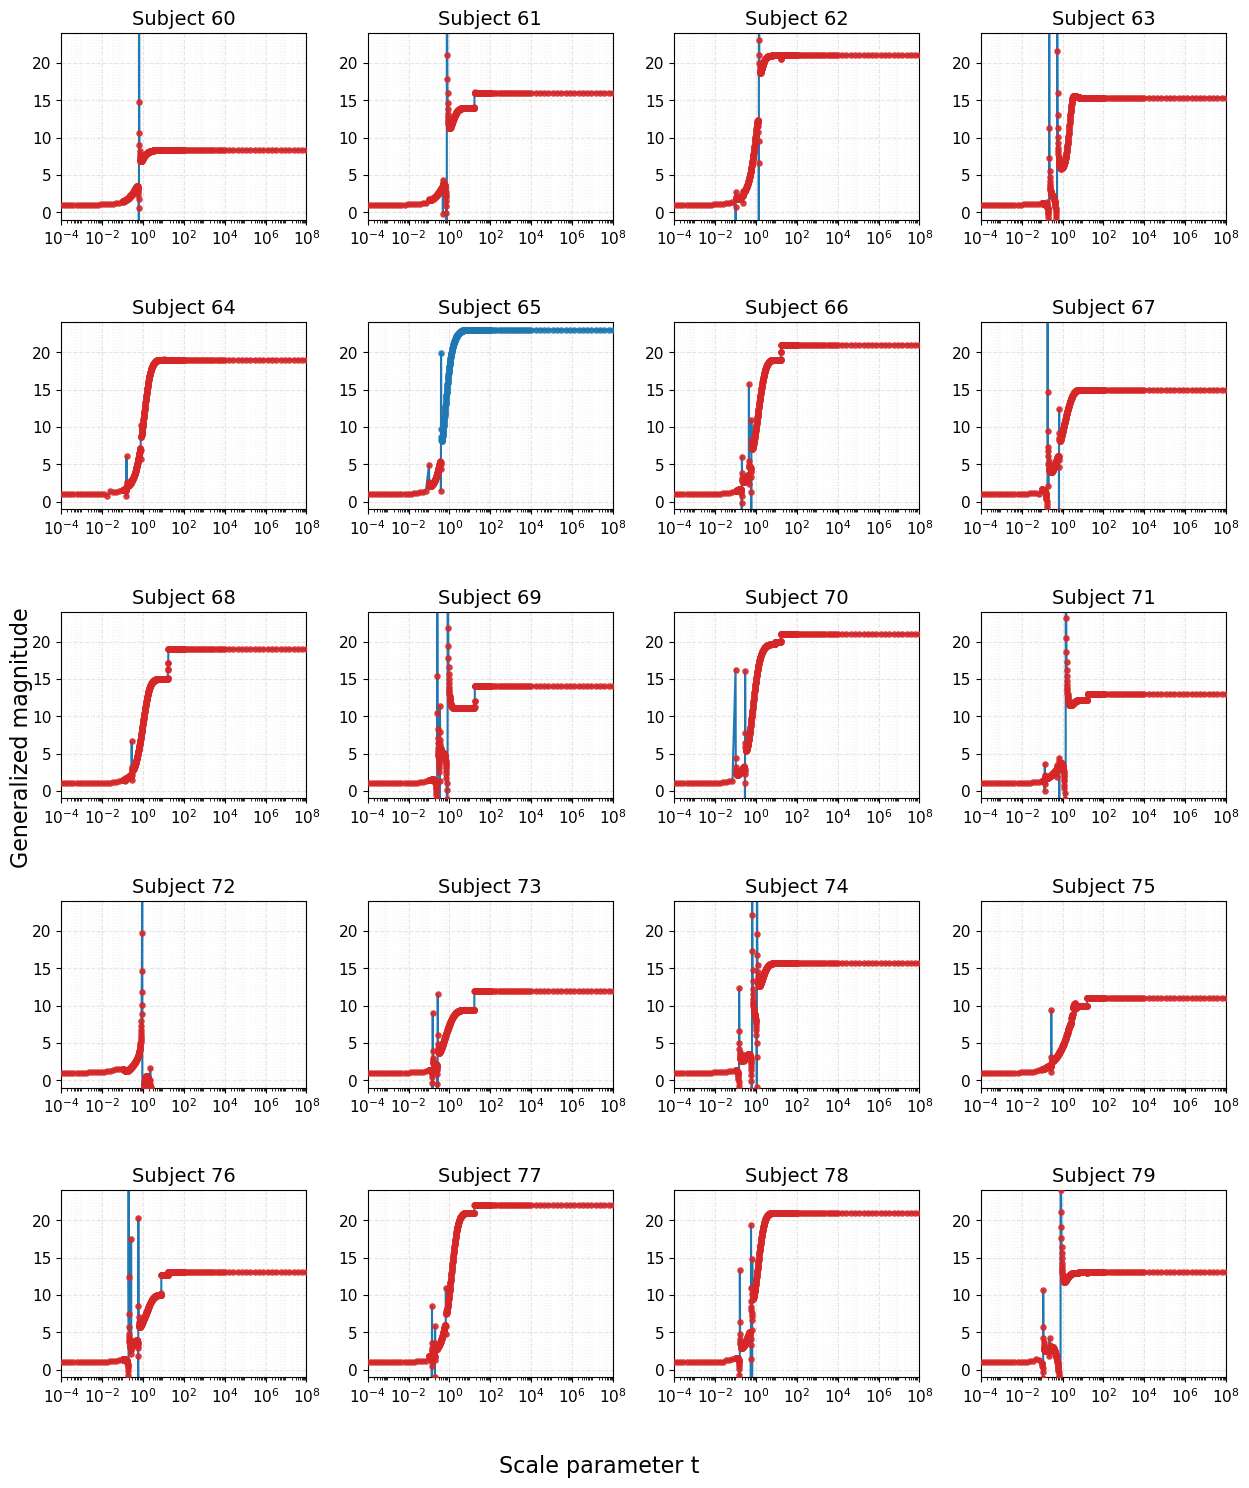

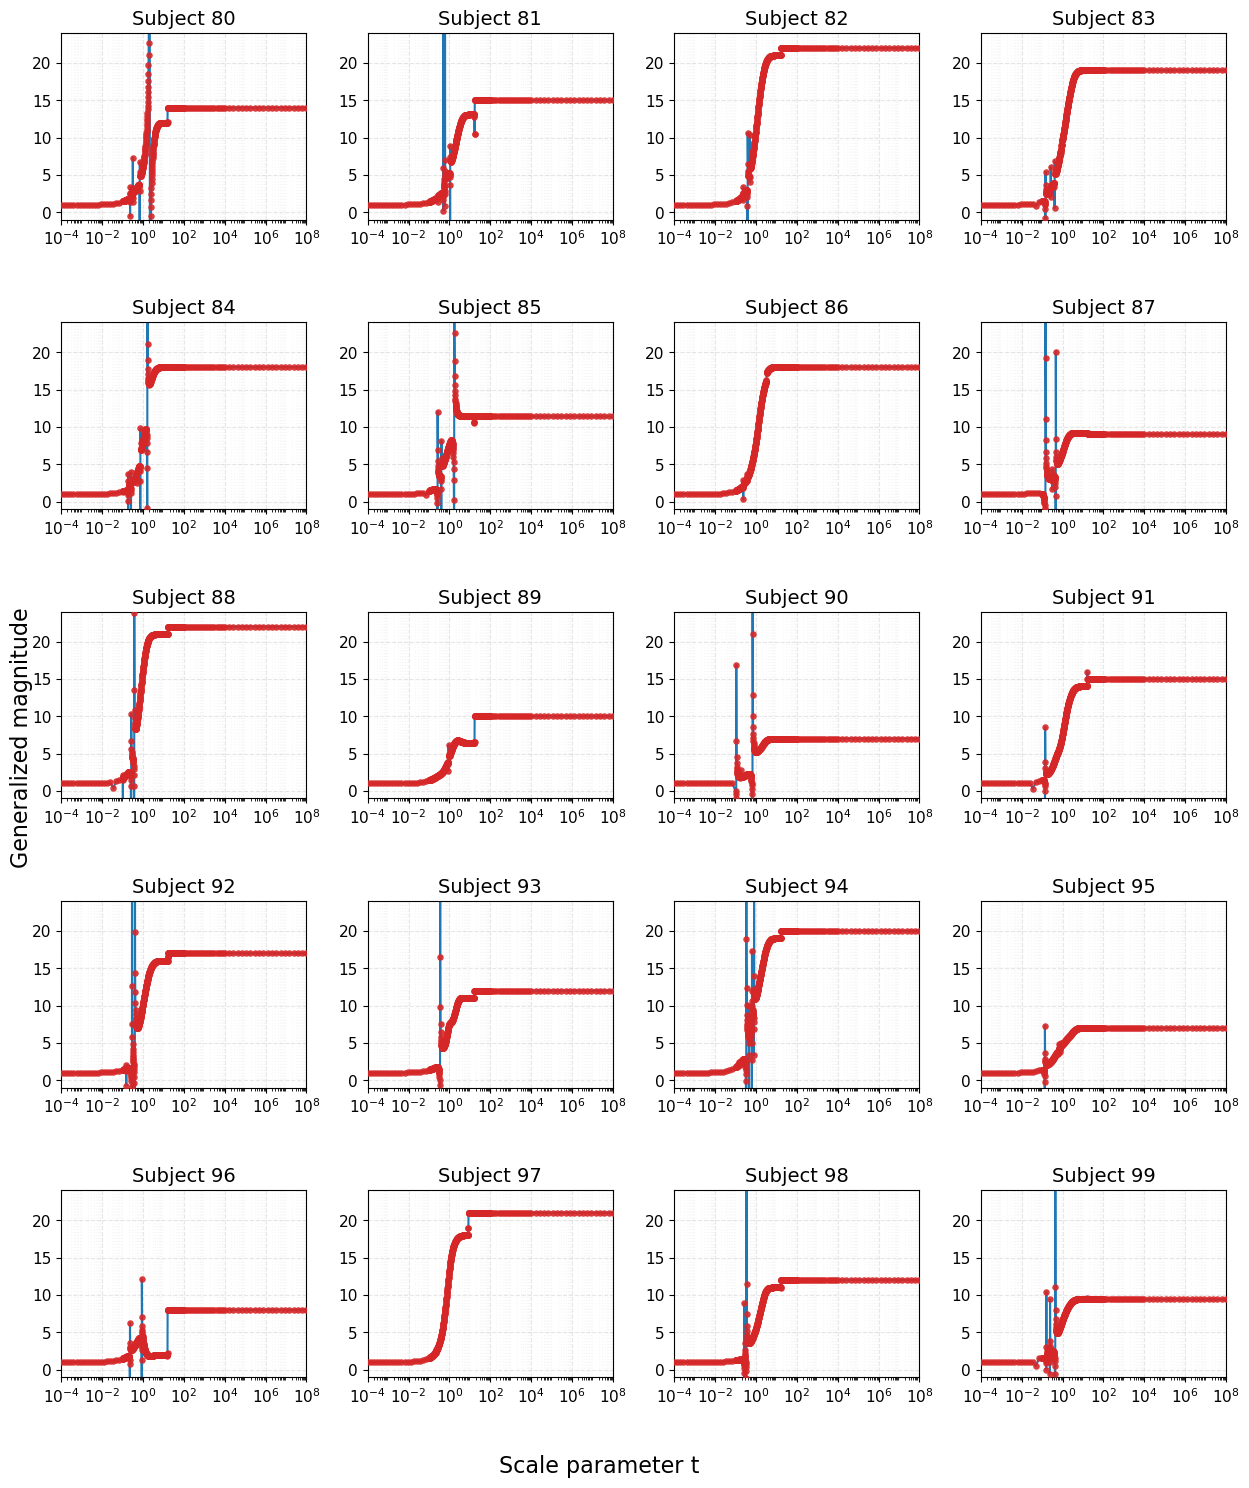

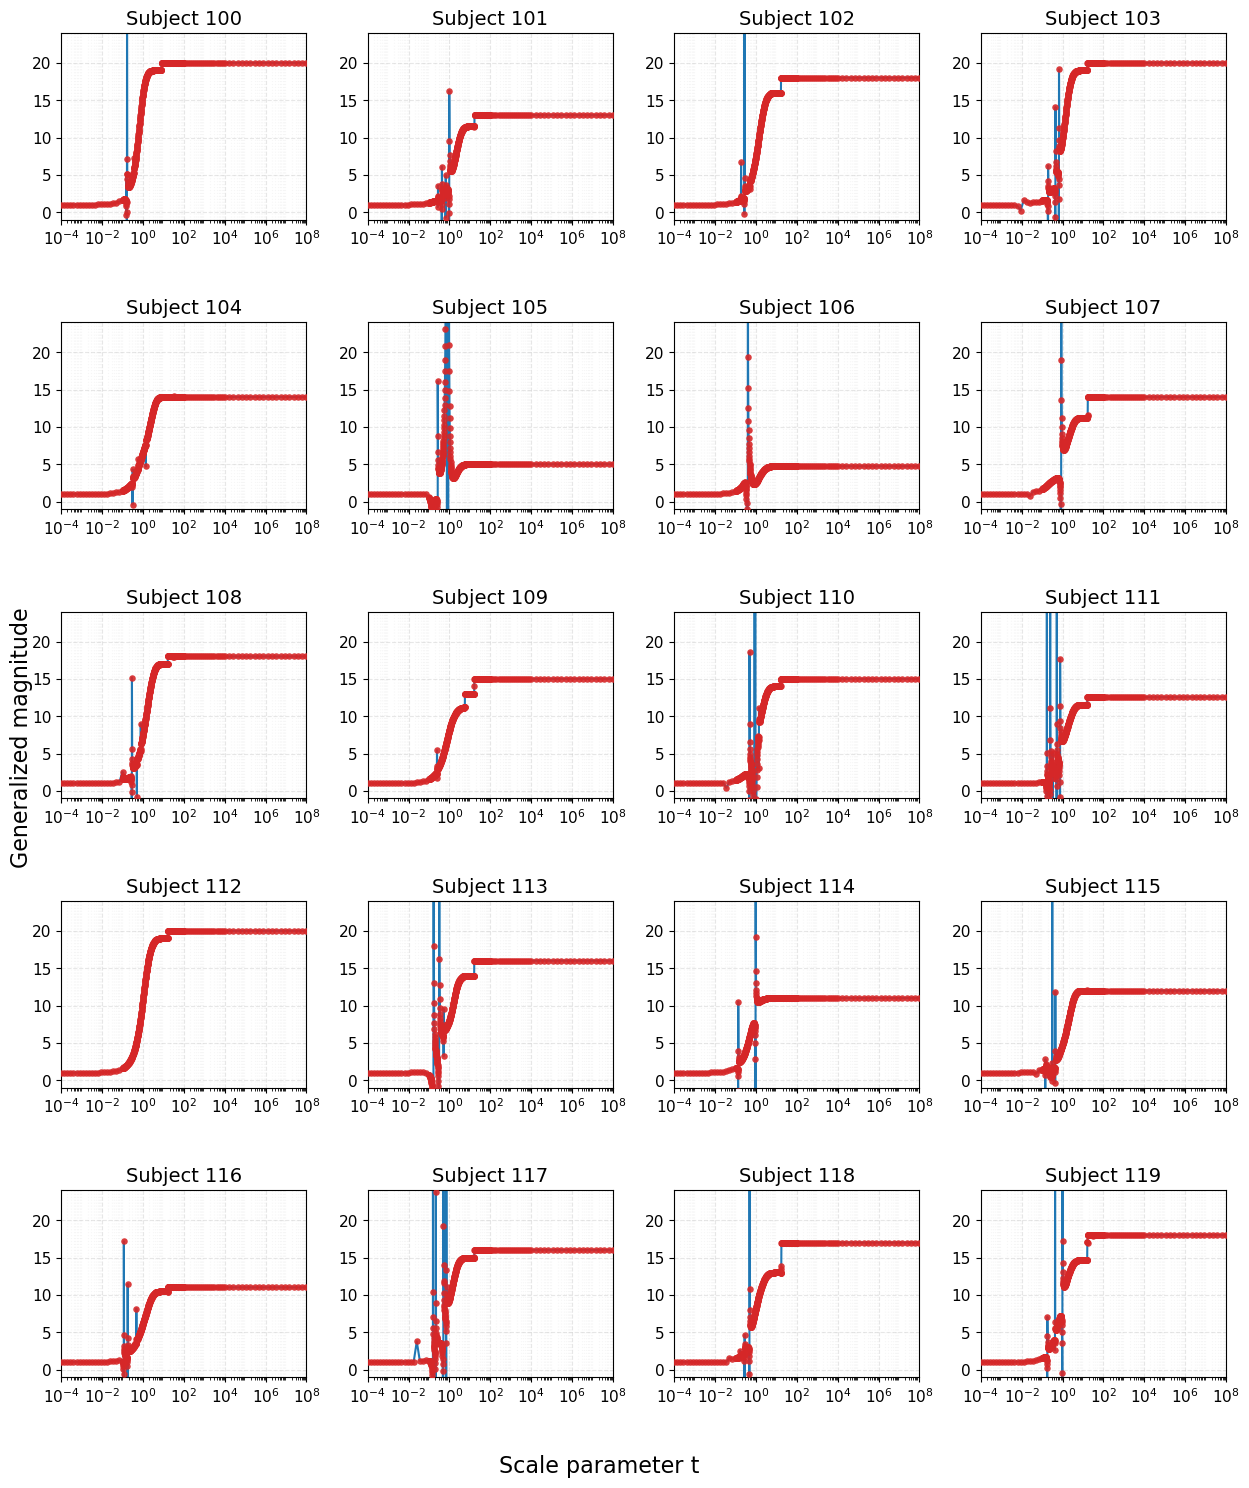

['/home/jovyan/work/fig/temp/Generalized magnitude_page01.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page02.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page03.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page04.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page05.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page06.png']

In [7]:
output = str(paths.figure("temp"))

viz.plt_metric_individual(
    genmag_all,
    metric_name="Generalized magnitude",
    output_dir=output,
    nrows=5, ncols=4,
    ylim=[-1, 24], xlim=None,
    xticks_all=True, yticks_all=True,
    positive_definite_df=positive_definite_t_all,
    posdef_mode= "two_color",
)

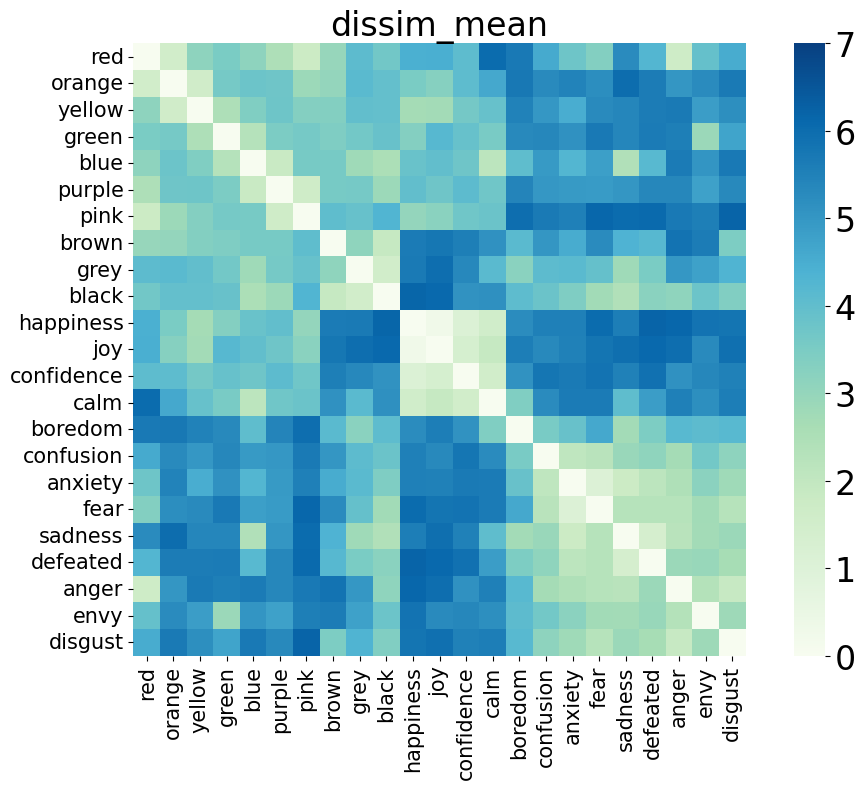

In [8]:
# all subjects mean
n_sub = 1
i_sub = 0

genmag_mean = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_mean = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_mean = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

dissim_mtx = core.create_dissim_amy(raw, sub_no=-1, unique_words=unique_words)
dist = core.cal_dissim2dist(dissim_mtx)

viz.plt_dissim_heatmap(
    dissim_mtx,
    mode_dissim=True,
    save=True,
    figpath=str(paths.figure("dissim", "dissim_mean.jpg")))

In [9]:
for i_t, t in enumerate(t_all):
    sim = core.cal_dist2sim(dist, t)
    genmag = core.cal_sim2genmag(sim)
    genmag_mean.iloc[0, i_t] = genmag

    spr = core.cal_dist2spread(dist, t)
    spr_mean.iloc[0, i_t] = spr

    A = sim.to_numpy()
    is_pd = core.check_positivedefinite(A)
    positive_definite_t_mean.iloc[i_sub, i_t] = bool(is_pd)

In [10]:
h5_path_mean = paths.interim("amy_processeddata_mean.h5")

positive_definite_df_mean = positive_definite_t_mean.astype("bool")
with pd.HDFStore(h5_path_mean, mode="w") as store:
    store.put("/dissim/mean", dissim_mtx, format="fixed")
    store.put("/metrics/genmag", genmag_mean, format="fixed")
    store.put("/metrics/spread", spr_mean, format="fixed")
    store.put("/metrics/positivedefinite", positive_definite_df_mean, format="fixed")